# 04 — Experiment 3: ambulatory motion

`E3_walk` — 180 s recording: 0-60 s seated, 60-120 s walking, 120-180 s recovery.

Anchor seated reference: **E1B** (sitting 5 min). Walking HRV is flagged
**unreliable** due to motion artifact; we still report it for completeness.

**Deliverables**:
- Figure 3.1 — full tachogram with segment shading.
- Figure 3.2 — raw ECG 15 s per segment (shows motion artifact in walking).
- Figure 3.3 — recovery HR with exponential tau fit.
- Figure 3.4 — ECG PSD seated vs walking (motion noise in 1-3 Hz).
- Figure 3.5 — motion-g(t) vs RR tachogram, Pearson corr during walking.
- Table 3.1 — per-segment stats + anchor comparison.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'paper_figures_png'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 15


## 1. Load pipeline + anchor + gsen

In [2]:
r  = P.analyze_transient_event("E3_walk")
r_anc = P.analyze_steady_state("E1B")
t_g, motion_g = P.load_gsen("E3_walk")
print(f"E3_walk:  {r.peaks_nk.size} peaks over {r.ecg_raw.size/cfg.FS:.1f}s")
print(f"E1B anchor: HR={r_anc.td_hrv['mean_hr_bpm']:.1f} bpm, HF={r_anc.fd_hrv['hf_ms2']:.0f} ms²")
for seg, d in r.extras["transient_hrv"].items():
    print(f"  {seg:10s}: HR={d['mean_hr_bpm']:.1f} bpm  RMSSD={d['rmssd_ms']:.1f}  "
          f"slope={d['hr_slope_bpm_per_s']:+.3f}  n_beats={d['n_beats']}")

E3_walk:  213 peaks over 180.0s
E1B anchor: HR=56.1 bpm, HF=1123 ms²
  seated    : HR=60.8 bpm  RMSSD=54.4  slope=-0.055  n_beats=60
  walking   : HR=83.0 bpm  RMSSD=41.1  slope=-0.120  n_beats=82
  recovery  : HR=70.3 bpm  RMSSD=46.9  slope=-0.134  n_beats=70


## 2. Figure 3.1 — full tachogram with segment shading

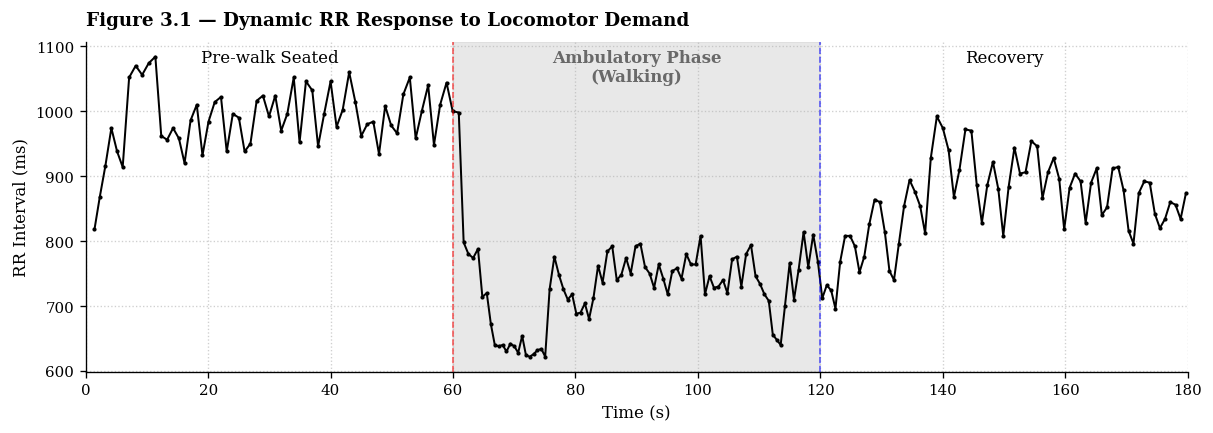

In [3]:
import matplotlib.pyplot as plt

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)

# 2. 繪製精緻的 Tachogram
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax, 
                     color='black', lw=1.2) # 在 E3 使用黑色線條會顯得更專業沉穩

# 3. 優化陰影與標記 (只 Highlight 步行區段)
t0, t1 = cfg.E3_SEG["walking"]
ax.axvspan(t0, t1, color='#D3D3D3', alpha=0.5, zorder=-1)
ax.axvline(t0, color='red', linestyle='--', alpha=0.6, lw=1)
ax.axvline(t1, color='blue', linestyle='--', alpha=0.6, lw=1)

# 加入專業標註
ax.text((t0+t1)/2, ax.get_ylim()[1] * 0.99, "Ambulatory Phase\n(Walking)", 
        ha="center", va="top", fontsize=10, fontweight='bold', color='dimgray')
ax.text(t0/2, ax.get_ylim()[1] * 0.99, "Pre-walk Seated", ha="center", va="top", fontsize=10)
ax.text(t1 + (180-t1)/2, ax.get_ylim()[1] * 0.99, "Recovery", ha="center", va="top", fontsize=10)

# 4. 座標與標題設定
ax.set_xlim(0, 180)
ax.set_xlabel("Time (s)")
ax.set_ylabel("RR Interval (ms)")
ax.set_title("Figure 3.1 — Dynamic RR Response to Locomotor Demand", loc='left', fontweight='bold', pad=10)
ax.grid(True, linestyle=':', alpha=0.6)

fig.savefig(FIG_DIR / "MAIN_08_nb04_exp3_walking_tachogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Figure 3.2 — raw ECG 15 s per segment (motion artifact visible)

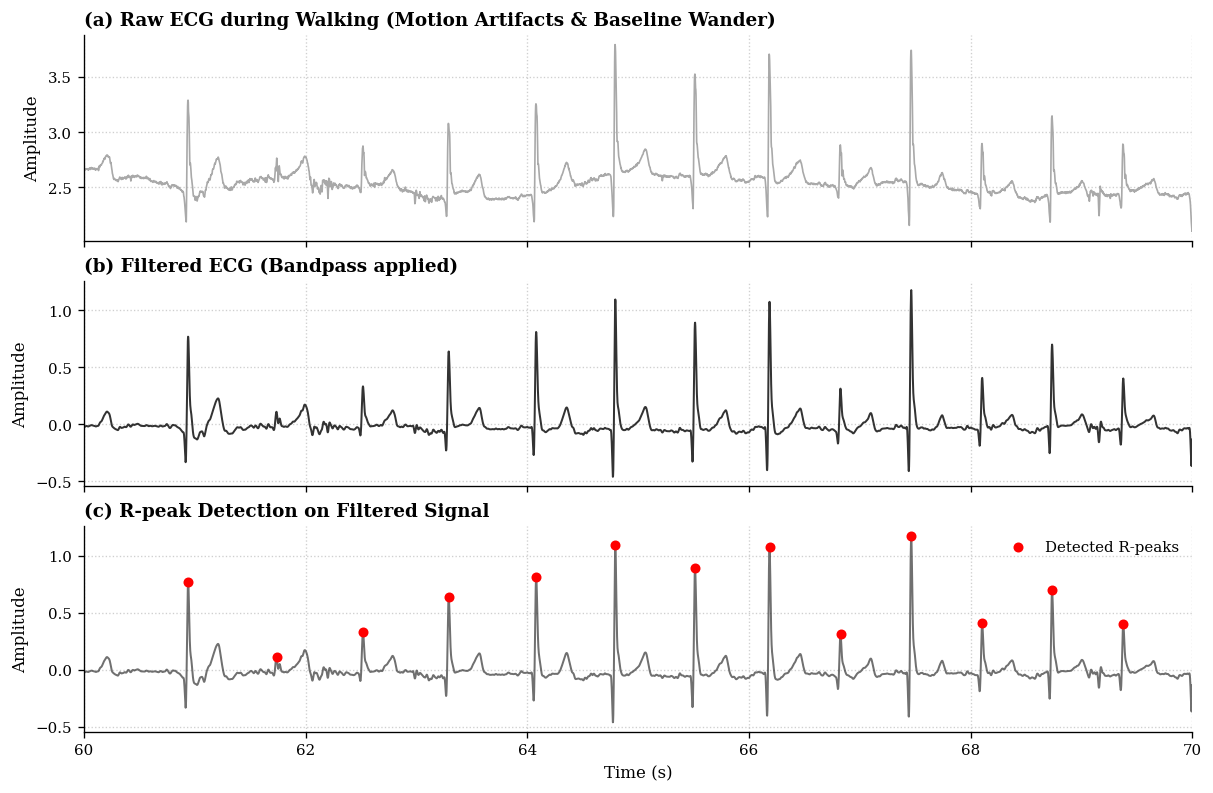

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

# 2. 挑選「步行階段」中最嚴峻的 10 秒鐘
t0w, t1w = cfg.E3_SEG["walking"]
view_start = t0w   # 假設步行開始
view_end = view_start + 10

# 找出對應的 index
i0 = int(view_start * cfg.FS)
i1 = int(view_end * cfg.FS)

t_view = r.t[i0:i1]
raw_view = r.ecg_raw[i0:i1]
filt_view = r.ecg_filt[i0:i1]

# 找出在這個視窗內的 R-peaks
valid_peaks = r.peaks_nk[(r.peaks_nk >= i0) & (r.peaks_nk < i1)]
peak_t = r.t[valid_peaks]
peak_y = r.ecg_filt[valid_peaks]

# 3. 建立 3x1 畫布
fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)

# (a) Raw ECG
axes[0].plot(t_view, raw_view, color="#A9A9A9", lw=1.0)
axes[0].set_title("(a) Raw ECG during Walking (Motion Artifacts & Baseline Wander)", loc='left', fontweight='bold')
axes[0].set_ylabel("Amplitude")

# (b) Filtered ECG
axes[1].plot(t_view, filt_view, color="#333333", lw=1.2)
axes[1].set_title("(b) Filtered ECG (Bandpass applied)", loc='left', fontweight='bold')
axes[1].set_ylabel("Amplitude")

# (c) Peak Detection
axes[2].plot(t_view, filt_view, color="#333333", lw=1.2, alpha=0.7)
axes[2].scatter(peak_t, peak_y, color="red", s=25, zorder=3, label="Detected R-peaks")
axes[2].set_title("(c) R-peak Detection on Filtered Signal", loc='left', fontweight='bold')
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc='upper right', fontsize=9)

# 統一網格
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

# 限制 X 軸顯示範圍
axes[-1].set_xlim(view_start, view_end)

fig.savefig(FIG_DIR / "MAIN_09_nb04_exp3_signal_processing_snapshots.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Figure 3.3 — recovery HR with exponential tau fit

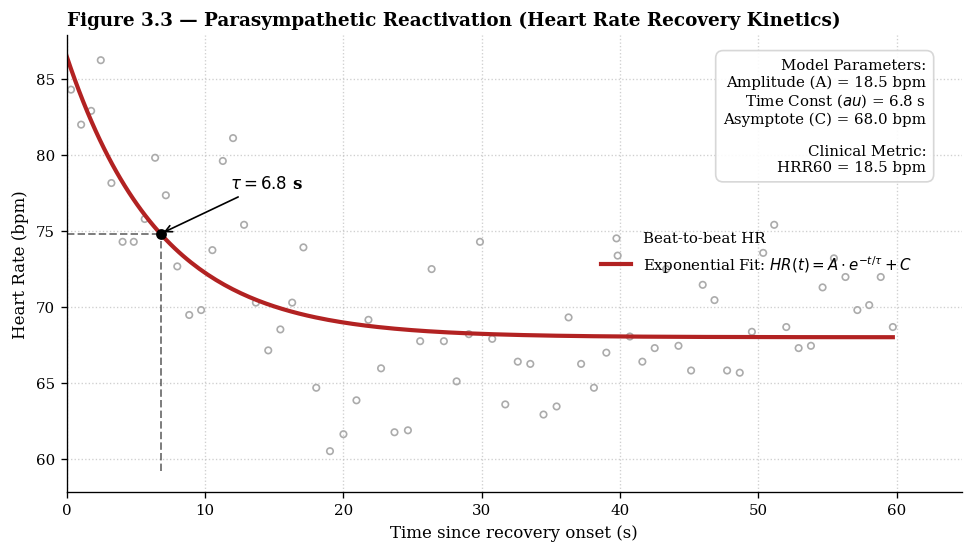

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9
})

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

t_rec0, t_rec1 = cfg.E3_SEG["recovery"]
mask = (r.rr_times_nk >= t_rec0) & (r.rr_times_nk < t_rec1)
t_rec = r.rr_times_nk[mask] - t_rec0
hr_rec = 60000.0 / r.rr_ms_nk[mask]

try:
    popt, _ = curve_fit(exp_decay, t_rec, hr_rec,
                        p0=[hr_rec[0]-hr_rec[-1], 20.0, hr_rec[-1]],
                        maxfev=5000)
    A, tau, C = popt
    t_fit = np.linspace(0, t_rec.max(), 200)
    hr_fit = exp_decay(t_fit, *popt)
    fit_ok = True
except Exception as exc:
    A = tau = C = float("nan"); fit_ok = False
    print(f"Fit failed: {exc}")

# 2. 開始繪製頂刊等級圖表
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

# 繪製原始數據 (使用灰色半透明，弱化高頻雜訊的干擾)
ax.scatter(t_rec, hr_rec, facecolor='none', edgecolor='#888888', s=15, alpha=0.7, label="Beat-to-beat HR")

if fit_ok:
    # 繪製擬合曲線 (使用搶眼的深紅色)
    ax.plot(t_fit, hr_fit, "-", color="#B22222", linewidth=2.5, 
            label=r"Exponential Fit: $HR(t) = A \cdot e^{-t/\tau} + C$")
    
    # 【關鍵視覺化】：標示 Tau 的位置 (下降 63.2%)
    hr_at_tau = exp_decay(tau, *popt)
    ax.plot([tau, tau], [ax.get_ylim()[0], hr_at_tau], 'k--', alpha=0.5, lw=1.2)
    ax.plot([0, tau], [hr_at_tau, hr_at_tau], 'k--', alpha=0.5, lw=1.2)
    ax.scatter([tau], [hr_at_tau], color='black', s=30, zorder=5)
    
    # 標註 Tau
    ax.annotate(rf'$\tau = {tau:.1f}$ s', xy=(tau, hr_at_tau), xytext=(tau + 5, hr_at_tau + 3),
                arrowprops=dict(arrowstyle="->", color='black', connectionstyle="arc3"),
                fontsize=10, fontweight='bold')

    # 計算臨床常用指標 HRR60 (Recovery after 1 minute)
    hr_0 = exp_decay(0, *popt)
    hr_60 = exp_decay(60, *popt)
    hrr_60 = hr_0 - hr_60

    # 製作精緻的數據面板
    stats_text = (
        f"Model Parameters:\n"
        f"Amplitude (A) = {A:.1f} bpm\n"
        f"Time Const ($\tau$) = {tau:.1f} s\n"
        f"Asymptote (C) = {C:.1f} bpm\n\n"
        f"Clinical Metric:\n"
        f"HRR60 = {hrr_60:.1f} bpm"
    )
    ax.text(0.96, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

ax.set_xlabel("Time since recovery onset (s)")
ax.set_ylabel("Heart Rate (bpm)")
ax.set_title("Figure 3.3 — Parasympathetic Reactivation (Heart Rate Recovery Kinetics)", loc='left', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', bbox_to_anchor=(0.96, 0.6))
ax.set_xlim(0, t_rec.max() + 5)

fig.savefig(FIG_DIR / "MAIN_10_nb04_exp3_recovery_tau_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Figure 3.4 — ECG PSD seated vs walking

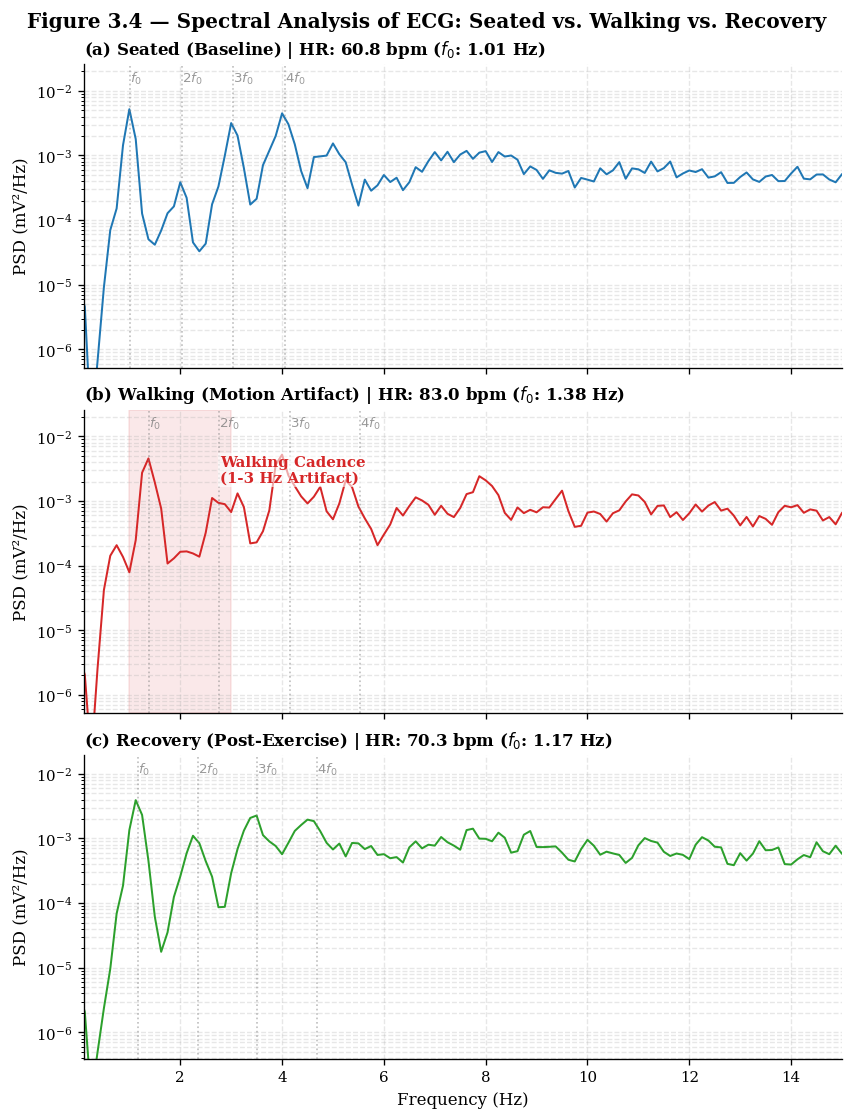

In [6]:
from matplotlib.transforms import blended_transform_factory

segments = ["seated", "walking", "recovery"]
seg_titles = {"seated": "Seated (Baseline)", "walking": "Walking (Motion Artifact)", "recovery": "Recovery (Post-Exercise)"}
colors = {"seated": "tab:blue", "walking": "tab:red", "recovery": "tab:green"}

fig, axes = plt.subplots(len(segments), 1, figsize=(7, 9), sharex=True, constrained_layout=True)

for i, (ax, seg_name) in enumerate(zip(axes, segments)):
    # 1. Get segment data
    t0, t1 = cfg.E3_SEG[seg_name]
    i0, i1 = int(t0 * cfg.FS), int(t1 * cfg.FS)
    ecg_seg = r.ecg_filt[i0:i1]
    
    # 2. Calculate PSD
    f, p = P.ecg_psd(ecg_seg, fs=cfg.FS, nperseg_sec=8)
    
    # 3. Get HR and f0 (fundamental frequency)
    hr = r.extras["transient_hrv"][seg_name]["mean_hr_bpm"]
    f0 = hr / 60.0
    
    # 4. Plot PSD
    ax.semilogy(f, p, color=colors[seg_name], lw=1.2, label=f"{seg_name.capitalize()} PSD")
    
    # 5. Add Harmonic Comb (f0, 2f0, 3f0, 4f0)
    harmonic_trans = blended_transform_factory(ax.transData, ax.transAxes)
    for k in range(1, 5):
        fk = k * f0
        if fk < 15.0:
            ax.axvline(fk, color="tab:gray", linestyle=":", alpha=0.5, lw=1)
            h_label = rf"$f_0$" if k == 1 else rf"${k}f_0$"
            ax.text(fk, 0.98, h_label, transform=harmonic_trans, ha="left", va="top",
                    fontsize=8, color="tab:gray", alpha=0.8)
    
    # 6. Specific annotations for Walking
    if seg_name == "walking":
        ax.axvspan(1.0, 3.0, color="tab:red", alpha=0.1, zorder=-1)
        ax.text(0.18, 0.85, "Walking Cadence\n(1-3 Hz Artifact)", transform=ax.transAxes,
                ha="left", va="top", fontsize=9, color="tab:red", fontweight="bold",
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
    
    # 7. Styling
    ax.set_xlim(0.1, 15.0)
    # Clamp Y axis to show relevant range (3-4 decades below peak)
    mask = (f > 0.5) & (f < 10)
    ymax = np.max(p[mask]) if np.any(mask) else np.max(p)
    ax.set_ylim(ymax / 10000, ymax * 5)
    
    ax.set_title(f"({chr(97+i)}) {seg_titles[seg_name]} | HR: {hr:.1f} bpm ($f_0$: {f0:.2f} Hz)", 
                 loc="left", fontsize=10, fontweight="bold")
    ax.set_ylabel("PSD (mV²/Hz)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Figure 3.4 — Spectral Analysis of ECG: Seated vs. Walking vs. Recovery", 
             fontsize=12, fontweight="bold", y=1.02)

fig.savefig(FIG_DIR / "MAIN_11_nb04_exp3_ecg_psd_rest_vs_walk.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Figure 3.5 — motion-g(t) vs RR tachogram + Pearson correlation

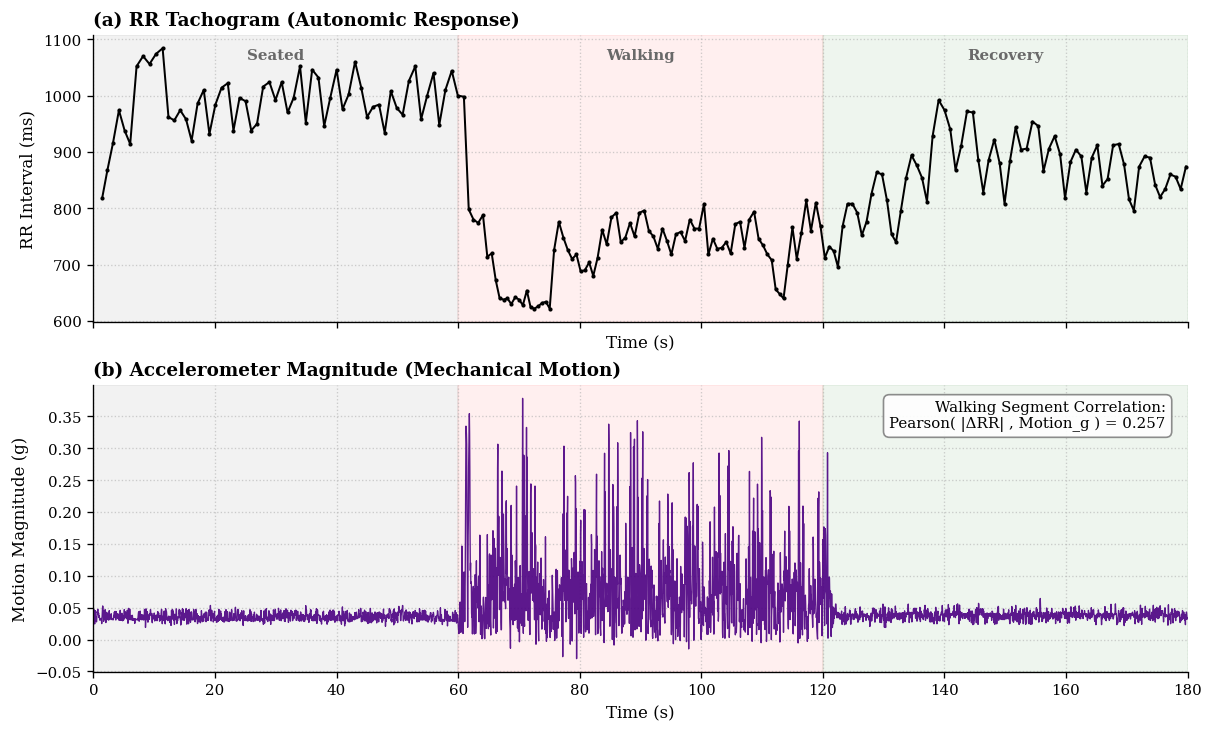

✅ Pearson corr(|ΔRR|, motion_g) during walking: 0.257


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

# 建立 2x1 共用 X 軸的畫布
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

# 定義陰影顏色 (確保不會報錯)
SEG_COLORS = {"seated": "#A9A9A9", "walking": "#FF9999", "recovery": "#8FBC8F"}

# ==========================================
# 上半部：RR Tachogram (心律軌跡)
# ==========================================
ax_rr = axes[0]
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax_rr, color='black', lw=1.2)
ax_rr.set_title("(a) RR Tachogram (Autonomic Response)", loc='left', fontweight='bold')
ax_rr.set_ylabel("RR Interval (ms)")
ax_rr.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 下半部：Accelerometer (步伐震動)
# ==========================================
ax_g = axes[1]
# 使用較細的線條以展現高頻的步伐震動
ax_g.plot(t_g, motion_g, color="#4B0082", linewidth=0.8, alpha=0.9)
ax_g.set_title("(b) Accelerometer Magnitude (Mechanical Motion)", loc='left', fontweight='bold')
ax_g.set_ylabel("Motion Magnitude (g)")
ax_g.set_xlabel("Time (s)")
ax_g.grid(True, linestyle=':', alpha=0.6)
ax_g.set_xlim(0, 180)

# ==========================================
# 繪製階段陰影與標註
# ==========================================
for name, (t0, t1) in cfg.E3_SEG.items():
    c = SEG_COLORS.get(name, "gray")
    ax_rr.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    ax_g.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    
    # 只在上方子圖標示階段名稱
    ax_rr.text((t0+t1)/2, ax_rr.get_ylim()[1] * 0.98, name.capitalize(),
               ha="center", va="top", fontsize=9, fontweight='bold', color='dimgray')

# ==========================================
# 核心計算：Pearson Correlation (Walking Phase)
# ==========================================
t0w, t1w = cfg.E3_SEG["walking"]

m_rr = (r.rr_times_nk >= t0w) & (r.rr_times_nk < t1w)
rr_w = r.rr_ms_nk[m_rr]
rt_w = r.rr_times_nk[m_rr]

m_g = (t_g >= t0w) & (t_g < t1w)
t_gw = t_g[m_g]
mg_w = motion_g[m_g]

if rr_w.size >= 3 and mg_w.size >= 3:
    # 你的絕佳邏輯：比較 ΔRR 與 Motion_g
    d_rr = np.abs(np.diff(rr_w))
    t_d  = rt_w[1:]
    mg_i = np.interp(t_d, t_gw, mg_w)
    mask = np.isfinite(d_rr) & np.isfinite(mg_i)
    
    if mask.sum() > 3:
        corr = float(np.corrcoef(d_rr[mask], mg_i[mask])[0, 1])
    else:
        corr = float("nan")
else:
    corr = float("nan")

# 在下方圖表加入精緻的統計資訊框
stats_text = f"Walking Segment Correlation:\nPearson( |ΔRR| , Motion_g ) = {corr:.3f}"
ax_g.text(0.98, 0.95, stats_text, transform=ax_g.transAxes,
          fontsize=9, color='black', ha='right', va='top',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray'))

# 存檔
fig.savefig(FIG_DIR / "MAIN_12_nb04_exp3_multimodal_fusion.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Pearson corr(|ΔRR|, motion_g) during walking: {corr:.3f}")

## 7. Table 3.1 — per-segment stats + anchor comparison

In [8]:
rows = []
for seg_name, d in r.extras["transient_hrv"].items():
    rows.append({
        "Segment": seg_name,
        "Range (s)": f"{cfg.E3_SEG[seg_name][0]:.0f}-{cfg.E3_SEG[seg_name][1]:.0f}",
        "n_beats":   d["n_beats"],
        "Mean HR (bpm)": d["mean_hr_bpm"],
        "Min HR (bpm)":  d["min_hr_bpm"],
        "Max HR (bpm)":  d["max_hr_bpm"],
        "RMSSD (ms)":    d["rmssd_ms"],
        "HR slope (bpm/s)": d["hr_slope_bpm_per_s"],
        "Note":      "**UNRELIABLE (motion)**" if seg_name == "walking" else "",
    })
rows.append({
    "Segment": "E1B anchor",
    "Range (s)": "300 (5 min)",
    "n_beats": int(r_anc.peaks_nk.size),
    "Mean HR (bpm)": r_anc.td_hrv["mean_hr_bpm"],
    "Min HR (bpm)":  r_anc.td_hrv["min_hr_bpm"],
    "Max HR (bpm)":  r_anc.td_hrv["max_hr_bpm"],
    "RMSSD (ms)":    r_anc.td_hrv["rmssd_ms"],
    "HR slope (bpm/s)": float("nan"),
    "Note": "seated reference",
})
df_t31 = pd.DataFrame(rows)
df_t31["Motion corr (Pearson)"] = ""
df_t31.loc[df_t31["Segment"]=="walking", "Motion corr (Pearson)"] = f"{corr:.3f}"
df_t31["Recovery τ (s)"] = ""
df_t31.loc[df_t31["Segment"]=="recovery", "Recovery τ (s)"] = f"{tau:.1f}" if fit_ok else ""
df_t31.to_csv(TBL_DIR / "table_3_1_walking.csv", index=False)
df_t31.style.set_caption("Table 3.1 — E3 segment HRV vs E1B sitting anchor")

,Segment,Range (s),n_beats,Mean HR (bpm),Min HR (bpm),Max HR (bpm),RMSSD (ms),HR slope (bpm/s),Note,Motion corr (Pearson),Recovery τ (s)
0,seated,0-60,60,60.844730,55.350554,73.349633,54.396535,-0.054605,,,
1,walking,60-120,82,83.047285,60.120240,96.463023,41.060630,-0.119521,**UNRELIABLE (motion)**,0.257,
2,recovery,120-180,70,70.284360,60.483871,86.206897,46.872630,-0.134047,,,6.8
3,E1B anchor,300 (5 min),279,56.097234,49.180328,71.090047,61.111174,nan,seated reference,,


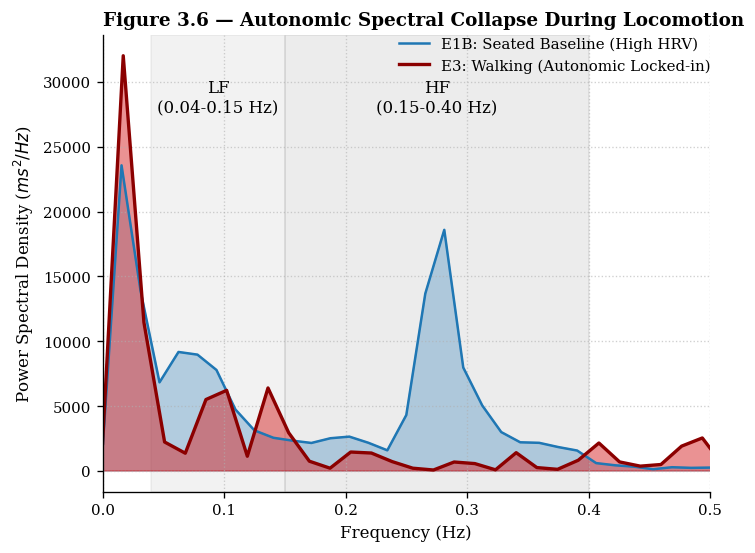

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

# 2. E1B (Sitting) — Welch PSD of interpolated RR (same path as fd_hrv scalars)
freqs_anc, psd_anc = P.rr_psd(r_anc.rr_ms_scipy, r_anc.rr_times_scipy)

# 3. E3 (Walking) — walking-segment RR only (transient_hrv has time-domain stats, not PSD)
t0w, t1w = cfg.E3_SEG["walking"]
mw = (r.rr_times_nk >= t0w) & (r.rr_times_nk < t1w)
freqs_walk, psd_walk = P.rr_psd(r.rr_ms_nk[mw], r.rr_times_nk[mw])

# 4. 繪製對比圖
# E1B Baseline (使用半透明藍色區域，展現充沛的自律神經能量)
ax.fill_between(freqs_anc, psd_anc, color='tab:blue', alpha=0.3)
ax.plot(freqs_anc, psd_anc, color='tab:blue', lw=1.5, label='E1B: Seated Baseline (High HRV)')

# E3 Walking (使用強烈的紅色線條，展現能量被壓平的狀態)
ax.fill_between(freqs_walk, psd_walk, color='tab:red', alpha=0.5)
ax.plot(freqs_walk, psd_walk, color='darkred', lw=2.0, label='E3: Walking (Autonomic Locked-in)')

# 5. 標記頻段區域 (LF / HF)
ax.axvspan(0.04, 0.15, color='gray', alpha=0.1, zorder=-1)
ax.text(0.095, ax.get_ylim()[1]*0.9, 'LF\n(0.04-0.15 Hz)', ha='center', va='top', color='black', fontsize=10)

ax.axvspan(0.15, 0.40, color='gray', alpha=0.15, zorder=-1)
ax.text(0.275, ax.get_ylim()[1]*0.9, 'HF\n(0.15-0.40 Hz)', ha='center', va='top', color='black', fontsize=10)

# 6. 排版優化
ax.set_xlim(0, 0.5) # RR PSD 通常只看到 0.5 Hz
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density ($ms^2/Hz$)')
ax.set_title('Figure 3.6 — Autonomic Spectral Collapse During Locomotion', loc='left', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(
    loc='upper right', bbox_to_anchor=(1.01, 1.01),
    borderaxespad=0, framealpha=0.9,
)

fig.savefig(FIG_DIR / "MAIN_13_nb04_exp3_rr_psd_contrast.png", dpi=300, bbox_inches="tight")
plt.show()